# AAPL Price Direction â€” Model Training & Evaluation
XGBoost vs Logistic Regression using sentiment + technical features.

## 1. Setup

In [2]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import os

from src.features.engineering import load_and_merge, temporal_split, get_feature_matrix
from src.evaluation.metrics import (
    evaluate_classifier, plot_roc_curve,
    plot_confusion_matrix, plot_feature_importance, backtest_simulation
)

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from xgboost import XGBClassifier

os.makedirs('figures', exist_ok=True)
print('Setup complete.')

Setup complete.


## 2. Load & Prepare Data

In [3]:
df = load_and_merge('../data/raw/final_dataset.csv')

train_df, test_df = temporal_split(df, split_date='2024-09-01')

X_train, y_train, FEATURES = get_feature_matrix(train_df)
X_test,  y_test,  _        = get_feature_matrix(test_df)

print(f"Features ({len(FEATURES)}): {FEATURES}")
print(f"X_train shape: {X_train.shape}  |  X_test shape: {X_test.shape}")

Train: 2023-01-25 → 2024-08-30 (403 rows)
Test:  2024-09-03 → 2024-12-30 (83 rows)
Train UP%: 55.1%  |  Test UP%: 59.0%
Features (13): ['avg_sentiment', 'rolling_3d_sentiment', 'rolling_7d_sentiment', 'daily_return', 'price_momentum_5d', 'high_low_range', 'ma_5', 'ma_10', 'volume', 'day_of_week', 'lagged_target', 'sentiment_std_5d', 'sentiment_vs_trend']
X_train shape: (403, 13)  |  X_test shape: (83, 13)


## 3. Logistic Regression

In [4]:
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(C=0.1, max_iter=1000, random_state=42))
])
lr_pipe.fit(X_train, y_train)

lr_results = evaluate_classifier(
    'Logistic Regression', lr_pipe,
    X_train, y_train, X_test, y_test
)


  Logistic Regression
Train Accuracy : 0.5608
Test  Accuracy : 0.5904
Gap (overfit)  : -0.0296  ✓ ok
ROC-AUC        : 0.5324
Avg Precision  : 0.6212

Confusion Matrix:
[[ 2 32]
 [ 2 47]]

Classification Report:
              precision    recall  f1-score   support

           0      0.500     0.059     0.105        34
           1      0.595     0.959     0.734        49

    accuracy                          0.590        83
   macro avg      0.547     0.509     0.420        83
weighted avg      0.556     0.590     0.477        83



In [5]:
# LR coefficients (inline â€” feature_importance uses .feature_importances_ so is XGBoost only)
lr_coefs = pd.Series(
    lr_pipe.named_steps['lr'].coef_[0],
    index=FEATURES
).sort_values(key=abs, ascending=False)

print("\nLogistic Regression Coefficients (sorted by |coef|):")
print(lr_coefs.to_string())


Logistic Regression Coefficients (sorted by |coef|):
daily_return            0.144518
price_momentum_5d      -0.096004
rolling_3d_sentiment    0.070203
sentiment_std_5d       -0.061596
high_low_range          0.047720
day_of_week             0.034767
ma_5                   -0.030720
ma_10                   0.029164
volume                 -0.023743
rolling_7d_sentiment   -0.011180
sentiment_vs_trend      0.003938
lagged_target          -0.001169
avg_sentiment           0.000024


## 4. XGBoost

In [6]:
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    early_stopping_rounds=20,
    random_state=42
)
xgb.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
print(f"Best iteration: {xgb.best_iteration}")

xgb_results = evaluate_classifier(
    'XGBoost', xgb,
    X_train, y_train, X_test, y_test
)

Best iteration: 20

  XGBoost
Train Accuracy : 0.7767
Test  Accuracy : 0.5663
Gap (overfit)  : 0.2104  ⚠ possible overfit
ROC-AUC        : 0.5984
Avg Precision  : 0.6678

Confusion Matrix:
[[ 6 28]
 [ 8 41]]

Classification Report:
              precision    recall  f1-score   support

           0      0.429     0.176     0.250        34
           1      0.594     0.837     0.695        49

    accuracy                          0.566        83
   macro avg      0.511     0.507     0.472        83
weighted avg      0.526     0.566     0.513        83



## 4b. Naive Baseline

In [7]:
dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train, y_train)

dummy_results = evaluate_classifier(
    'Naive Baseline (always predict majority class)', dummy,
    X_train, y_train, X_test, y_test
)


  Naive Baseline (always predict majority class)
Train Accuracy : 0.5509
Test  Accuracy : 0.5904
Gap (overfit)  : -0.0395  ✓ ok
ROC-AUC        : 0.5000
Avg Precision  : 0.5904

Confusion Matrix:
[[ 0 34]
 [ 0 49]]

Classification Report:
              precision    recall  f1-score   support

           0      0.000     0.000     0.000        34
           1      0.590     1.000     0.742        49

    accuracy                          0.590        83
   macro avg      0.295     0.500     0.371        83
weighted avg      0.349     0.590     0.438        83



## 5. Model Comparison â€” ROC Curves

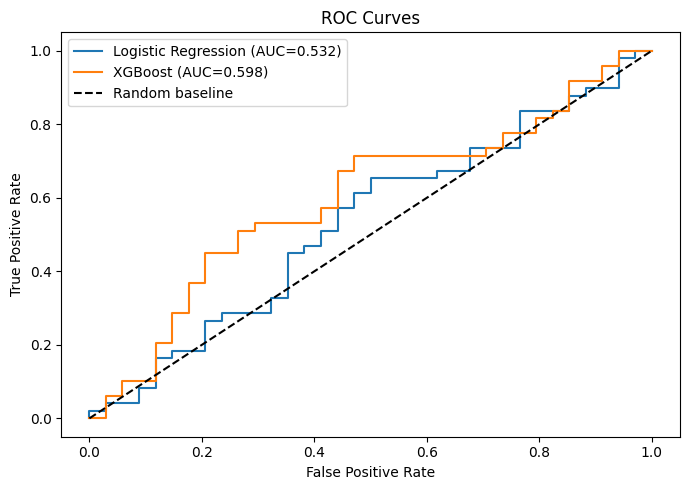

Model Comparison Summary:
                                                train_acc  test_acc       gap   roc_auc  avg_precision
model                                                                                                 
Naive Baseline (always predict majority class)   0.550868  0.590361 -0.039493  0.500000       0.590361
Logistic Regression                              0.560794  0.590361 -0.029567  0.532413       0.621211
XGBoost                                          0.776675  0.566265  0.210410  0.598439       0.667758


In [8]:
models_dict = {
    'Logistic Regression': lr_pipe,
    'XGBoost': xgb,
}
plot_roc_curve(models_dict, X_test, y_test)

# Summary table (dummy included separately — no predict_proba for ROC)
summary = pd.DataFrame([dummy_results, lr_results, xgb_results]).set_index('model')
print("Model Comparison Summary:")
print(summary[['train_acc', 'test_acc', 'gap', 'roc_auc', 'avg_precision']].to_string())

## 6. XGBoost Feature Importance

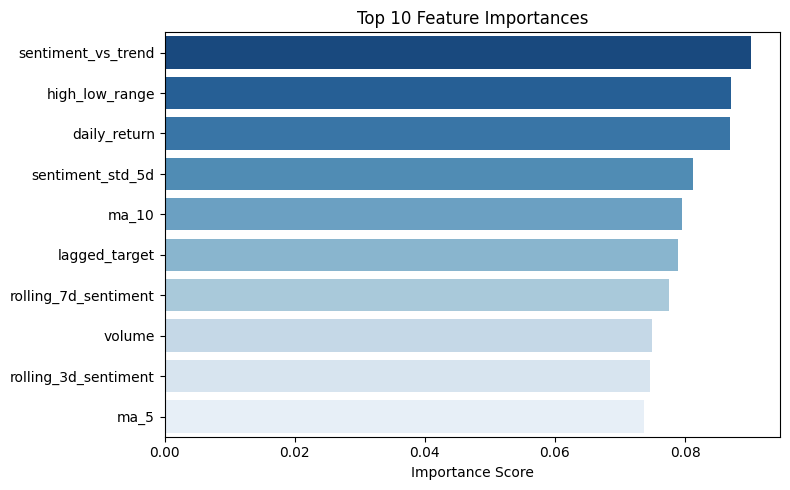

In [9]:
plot_feature_importance(xgb, FEATURES, top_n=10)

## 3. Cross-Validation

Cross-validation evaluates model performance across multiple data folds, providing a more reliable estimate of generalization than a single train/test split. A high standard deviation across folds indicates instability.

In [10]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# XGBoost without early_stopping_rounds for CV compatibility
xgb_base_cv = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

models_for_cv = {
    'XGBoost Baseline': xgb_base_cv,
    'Logistic Regression': lr_pipe,
}

scoring_metrics = ['accuracy', 'roc_auc', 'f1_weighted']
cv_results = {}

for model_name, model in models_for_cv.items():
    scores = {}
    for metric in scoring_metrics:
        s = cross_val_score(model, X_train, y_train, cv=cv, scoring=metric, n_jobs=-1)
        scores[metric] = s
    cv_results[model_name] = scores

print(f"{'Model':<25} {'CV Accuracy':<20} {'CV ROC-AUC':<20} {'CV F1':<20}")
print("-" * 85)
for model_name, scores in cv_results.items():
    acc = scores['accuracy']
    auc = scores['roc_auc']
    f1  = scores['f1_weighted']
    print(f"{model_name:<25} {acc.mean():.3f} +/- {acc.std():.3f}  "
          f"{auc.mean():.3f} +/- {auc.std():.3f}  "
          f"{f1.mean():.3f} +/- {f1.std():.3f}")

# Store for final comparison table
xgb_cv_roc_mean = cv_results['XGBoost Baseline']['roc_auc'].mean()
xgb_cv_roc_std  = cv_results['XGBoost Baseline']['roc_auc'].std()
lr_cv_roc_mean  = cv_results['Logistic Regression']['roc_auc'].mean()
lr_cv_roc_std   = cv_results['Logistic Regression']['roc_auc'].std()

Model                     CV Accuracy          CV ROC-AUC           CV F1               
-------------------------------------------------------------------------------------
XGBoost Baseline          0.531 +/- 0.039  0.507 +/- 0.056  0.524 +/- 0.040
Logistic Regression       0.504 +/- 0.042  0.425 +/- 0.027  0.448 +/- 0.057


## 4. Hyperparameter Tuning — Optuna

Optuna uses Bayesian optimization to efficiently search the hyperparameter space, requiring fewer evaluations than exhaustive grid search while finding stronger configurations. Each trial is evaluated via 5-fold cross-validation to prevent overfitting to the test set.

In [11]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 100, 600),
        'max_depth':        trial.suggest_int('max_depth', 2, 6),
        'learning_rate':    trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        'subsample':        trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 5, 20),
        'reg_alpha':        trial.suggest_float('reg_alpha', 0.1, 5.0),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1.0, 10.0),
        'eval_metric': 'logloss',
        'random_state': 42,
    }
    model = XGBClassifier(**params)
    cv_opt = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train, y_train, cv=cv_opt,
                             scoring='roc_auc', n_jobs=-1)
    return scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

print(f"Best ROC-AUC (CV): {study.best_value:.4f}")
print(f"Best params: {study.best_params}")

Best ROC-AUC (CV): 0.5208
Best params: {'n_estimators': 107, 'max_depth': 3, 'learning_rate': 0.00421121544396788, 'subsample': 0.9066154808582114, 'colsample_bytree': 0.7668631340805557, 'min_child_weight': 16, 'reg_alpha': 0.3166333192031584, 'reg_lambda': 6.585037145274237}


In [12]:
best_params = dict(study.best_params)
best_params.update({'eval_metric': 'logloss', 'random_state': 42})

xgb_tuned = XGBClassifier(**best_params)
xgb_tuned.fit(X_train, y_train)

xgb_tuned_results = evaluate_classifier(
    'XGBoost Tuned (Optuna)', xgb_tuned,
    X_train, y_train, X_test, y_test
)


  XGBoost Tuned (Optuna)
Train Accuracy : 0.5509
Test  Accuracy : 0.5904
Gap (overfit)  : -0.0395  ✓ ok
ROC-AUC        : 0.4898
Avg Precision  : 0.6012

Confusion Matrix:
[[ 0 34]
 [ 0 49]]

Classification Report:
              precision    recall  f1-score   support

           0      0.000     0.000     0.000        34
           1      0.590     1.000     0.742        49

    accuracy                          0.590        83
   macro avg      0.295     0.500     0.371        83
weighted avg      0.349     0.590     0.438        83



In [13]:
comparison_df = pd.DataFrame([xgb_results, xgb_tuned_results])[['model', 'train_acc', 'test_acc', 'gap', 'roc_auc']]
comparison_df.columns = ['Model', 'Train Acc', 'Test Acc', 'Gap', 'ROC-AUC']
print("\nBaseline vs Tuned Comparison:")
print(comparison_df.to_string(index=False))


Baseline vs Tuned Comparison:
                 Model  Train Acc  Test Acc       Gap  ROC-AUC
               XGBoost   0.776675  0.566265  0.210410 0.598439
XGBoost Tuned (Optuna)   0.550868  0.590361 -0.039493 0.489796


## 5. Model Explainability — SHAP

SHAP (SHapley Additive exPlanations) uses game-theoretic Shapley values to explain each feature's contribution to individual predictions. All explanations use the tuned XGBoost model (`xgb_tuned`) and are computed on `X_train` for global interpretability.

In [14]:
import shap
import matplotlib.pyplot as plt

explainer = shap.TreeExplainer(xgb_tuned)
shap_values = explainer(X_train)
print("SHAP values computed.")

SHAP values computed.


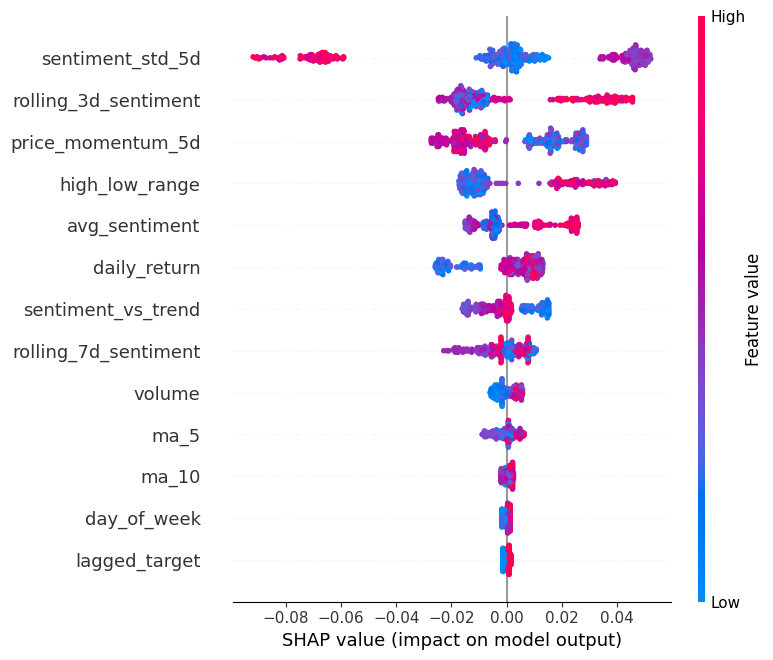

In [15]:
shap.summary_plot(shap_values, X_train, feature_names=FEATURES, show=False)
plt.savefig('figures/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

Red = high feature value, Blue = low. Features at the top have the most impact on predictions. A positive SHAP value pushes the prediction toward UP.

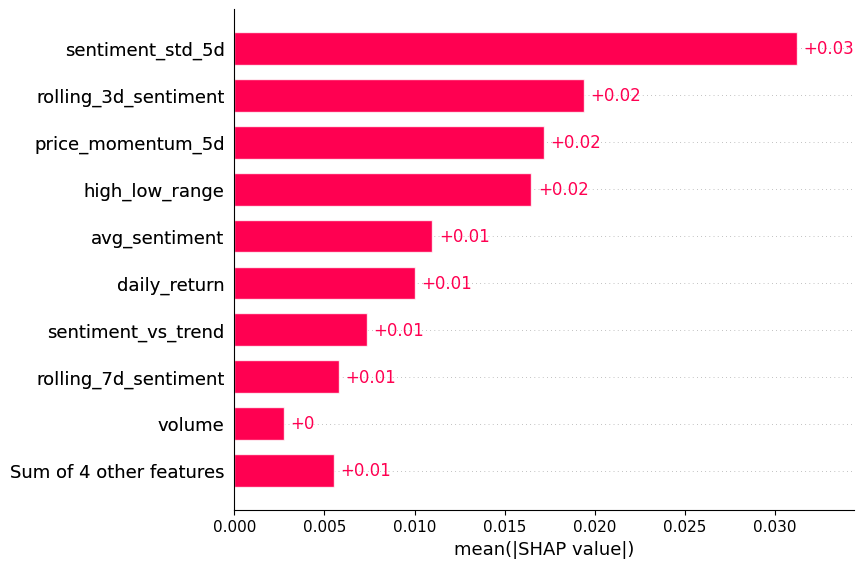

In [16]:
shap.plots.bar(shap_values, max_display=10, show=False)
plt.savefig('figures/shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

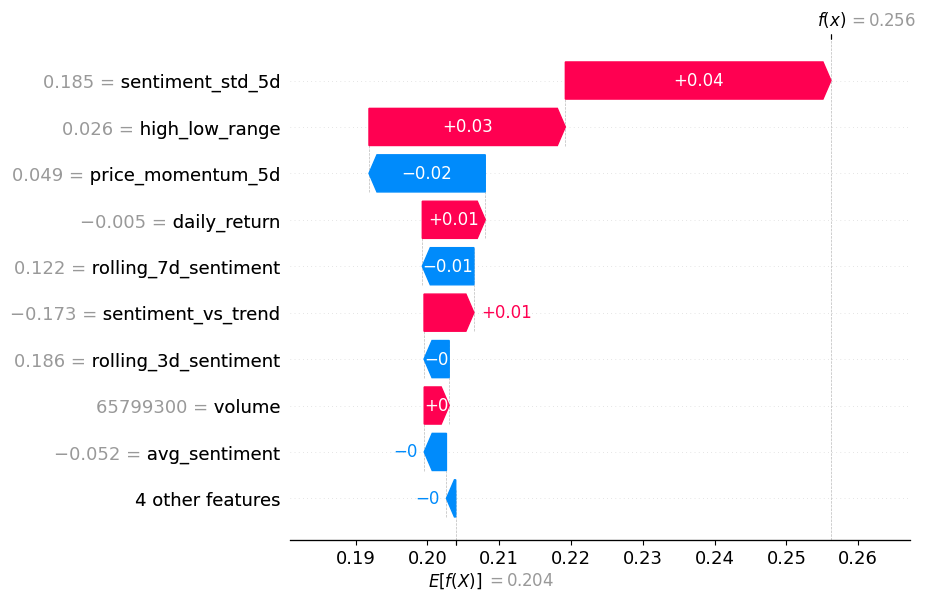

In [17]:
shap.plots.waterfall(shap_values[0], show=False)
plt.savefig('figures/shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

This waterfall plot breaks down a single prediction, showing exactly which features pushed the model toward UP or DOWN and by how much.

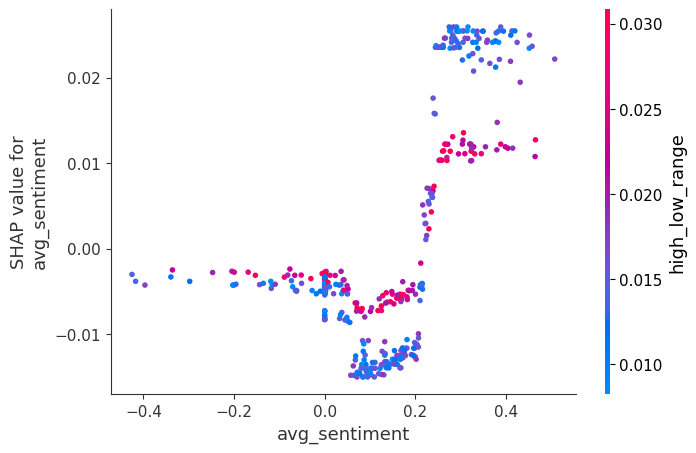

In [18]:
shap.dependence_plot('avg_sentiment', shap_values.values, X_train, feature_names=FEATURES, show=False)
plt.savefig('figures/shap_dependence.png', dpi=150, bbox_inches='tight')
plt.show()

This plot reveals whether the relationship between avg_sentiment and its SHAP value is monotonic or whether the effect changes at certain sentiment thresholds.

## 6. Final Model Comparison

The definitive summary of all models before the backtest. Columns include cross-validation ROC-AUC (from the training set only), test-set metrics, and overfit gap.

In [19]:
# Compute CV ROC-AUC for tuned model
tuned_cv_scores = cross_val_score(xgb_tuned, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)

rows = [
    {
        'Model': 'XGBoost Baseline',
        'CV ROC-AUC (mean +/- std)': f"{xgb_cv_roc_mean:.3f} +/- {xgb_cv_roc_std:.3f}",
        'Test Accuracy': f"{xgb_results['test_acc']:.3f}",
        'Test ROC-AUC': f"{xgb_results['roc_auc']:.3f}",
        'Overfit Gap': f"{xgb_results['gap']:.3f}",
    },
    {
        'Model': 'XGBoost Tuned (Optuna)',
        'CV ROC-AUC (mean +/- std)': f"{tuned_cv_scores.mean():.3f} +/- {tuned_cv_scores.std():.3f}",
        'Test Accuracy': f"{xgb_tuned_results['test_acc']:.3f}",
        'Test ROC-AUC': f"{xgb_tuned_results['roc_auc']:.3f}",
        'Overfit Gap': f"{xgb_tuned_results['gap']:.3f}",
    },
    {
        'Model': 'Logistic Regression',
        'CV ROC-AUC (mean +/- std)': f"{lr_cv_roc_mean:.3f} +/- {lr_cv_roc_std:.3f}",
        'Test Accuracy': f"{lr_results['test_acc']:.3f}",
        'Test ROC-AUC': f"{lr_results['roc_auc']:.3f}",
        'Overfit Gap': f"{lr_results['gap']:.3f}",
    },
]

final_summary = pd.DataFrame(rows)
print("\nFinal Model Comparison:")
print(final_summary.to_string(index=False))


Final Model Comparison:
                 Model CV ROC-AUC (mean +/- std) Test Accuracy Test ROC-AUC Overfit Gap
      XGBoost Baseline           0.507 +/- 0.056         0.566        0.598       0.210
XGBoost Tuned (Optuna)           0.521 +/- 0.045         0.590        0.490      -0.039
   Logistic Regression           0.425 +/- 0.027         0.590        0.532      -0.030


## 7. Backtest Simulation
Long-only strategy: buy AAPL on days the best model predicts UP.

Best model by ROC-AUC: XGBoost

  Backtest Results (Test Period)
Strategy return  : 9.3%
Buy-hold return  : 10.3%
Days traded      : 69 / 83


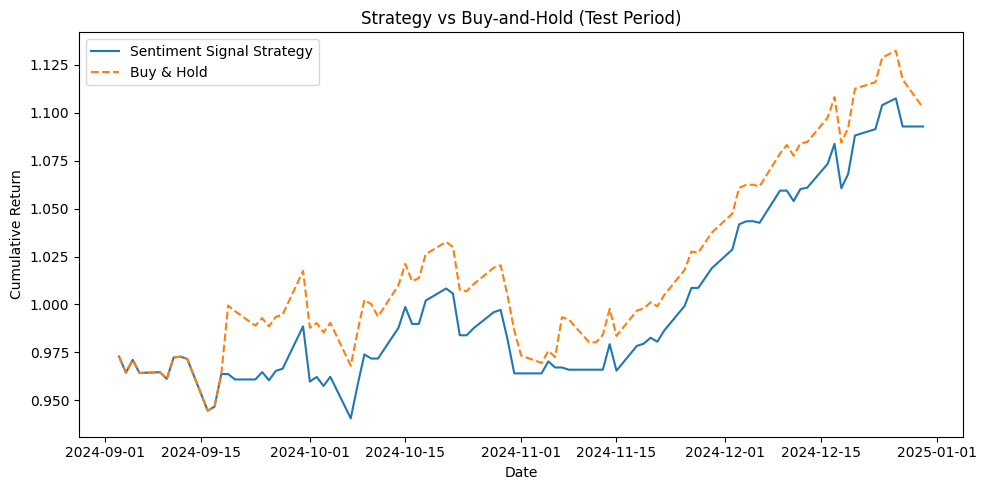

In [20]:
# Use whichever model has higher ROC-AUC
best_model_name = max([lr_results, xgb_results], key=lambda r: r['roc_auc'])['model']
best_model = models_dict[best_model_name]
print(f"Best model by ROC-AUC: {best_model_name}")

backtest_results = backtest_simulation(
    best_model, X_test, y_test,
    test_df.reset_index(drop=True)
)